<a href="https://colab.research.google.com/github/m4tss0/Calculo-Numerico-2026-2/blob/main/Atividade_1_C%C3%A1lculo_Num%C3%A9rico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 1 - Cálculo Numérico

**Nome:** Mateus de Lima Alencar Soares  
**RA:** 185301  
**Turma:** Noturno  
### Tarefas: Realizadas por Mateus

## Parte A - Truncamento e Arredondamento

Valores considerados:

x1 = 3,14159265, x2 = 98,76543, x3 = 0,00498765

(Utilizando n = 0, 1, 2, 3, 4 casas decimais)

#### 1° Passo:
Cálculo da aproximação por truncamento e por arredondamento

Cálculo de Ea, Er e E%

In [4]:
# Importa a biblioteca de funções matemáticas da linguagem Python.
import math
# Importa a biblioteca NumPy para manipulação numérica.
import numpy as np
# Importa o módulo pyplot para geração de gráficos.
import matplotlib.pyplot as plt
# Importa a biblioteca Pandas para organização e exibição tabular dos dados.
import pandas as pd

# Define o estilo visual claro padrão adotado no curso.
plt.style.use("seaborn-v0_8-whitegrid")

def truncar(numero, casas):
    """
    Trunca um número em uma determinada quantidade de casas decimais
    sem aplicar arredondamento.
    """
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

def calcular_erros(referencia, aproximacao):
    """
    Calcula os erros absoluto, relativo e percentual entre o valor
    de referência e a aproximação fornecida.
    """
    # Calcula o erro absoluto (módulo da diferença)
    erro_abs = abs(referencia - aproximacao)

    # Trata divisão por zero no cálculo do erro relativo
    if referencia == 0.0:
        erro_rel = np.nan
        erro_perc = np.nan
    else:
        erro_rel = erro_abs / abs(referencia)
        erro_perc = 100.0 * erro_rel

    return erro_abs, erro_rel, erro_perc

print("Ambiente preparado e funções base definidas com sucesso!")

Ambiente preparado e funções base definidas com sucesso!


#### 2° Passo:
Organização dos resultados em uma tabela

In [5]:
# Dicionário com os valores de referência fornecidos na Parte A
valores_teste = {
    "x1 (3.14159265)": 3.14159265,
    "x2 (98.76543)": 98.76543,
    "x3 (0.00498765)": 0.00498765
}

# Lista de casas decimais a serem testadas
casas_n = [0, 1, 2, 3, 4]

# Lista para armazenar todos os registros calculados
registros = []

for nome_val, x_ref in valores_teste.items():
    for n in casas_n:
        # 1. Aproximações
        x_trunc = truncar(x_ref, n)
        x_round = round(x_ref, n)

        # 2. Cálculo dos erros para Truncamento
        ea_t, er_t, ep_t = calcular_erros(x_ref, x_trunc)

        # 2. Cálculo dos erros para Arredondamento
        ea_r, er_r, ep_r = calcular_erros(x_ref, x_round)

        # Armazena os dados na lista
        registros.append({
            "Variável": nome_val,
            "n": n,
            "x_ref": x_ref,
            "x_trunc": x_trunc,
            "Ea_trunc": ea_t,
            "Er_trunc": er_t,
            "E%_trunc": ep_t,
            "x_round": x_round,
            "Ea_round": ea_r,
            "Er_round": er_r,
            "E%_round": ep_r
        })

# 3. Organização dos resultados em um DataFrame do Pandas
df_resultados = pd.DataFrame(registros)

# Formatação para visualização limpa no notebook
pd.set_option('display.float_format', lambda x: f'{x:.8e}' if abs(x) < 1e-3 and x != 0 else f'{x:.6f}')
display(df_resultados)

,Variável,n,x_ref,x_trunc,Ea_trunc,Er_trunc,E%_trunc,x_round,Ea_round,Er_round,E%_round
0,x1 (3.14159265),0,3.141593,3.000000,0.141593,0.045070,4.507034,3.000000,0.141593,0.045070,4.507034
1,x1 (3.14159265),1,3.141593,3.100000,0.041593,0.013239,1.323935,3.100000,0.041593,0.013239,1.323935
2,x1 (3.14159265),2,3.141593,3.140000,0.001593,5.06956241e-04,0.050696,3.140000,0.001593,5.06956241e-04,0.050696
3,x1 (3.14159265),3,3.141593,3.141000,5.92650000e-04,1.88646354e-04,0.018865,3.142000,4.07350000e-04,1.29663532e-04,0.012966
4,x1 (3.14159265),4,3.141593,3.141500,9.26500000e-05,2.94914110e-05,0.002949,3.141600,7.35000000e-06,2.33957767e-06,2.33957767e-04
5,x2 (98.76543),0,98.765430,98.000000,0.765430,0.007750,0.774998,99.000000,0.234570,0.002375,0.237502
6,x2 (98.76543),1,98.765430,98.700000,0.065430,6.62478764e-04,0.066248,98.800000,0.034570,3.50021257e-04,0.035002
7,x2 (98.76543),2,98.765430,98.760000,0.005430,5.49787512e-05,0.005498,98.770000,0.004570,4.62712510e-05,0.004627
8,x2 (98.76543),3,98.765430,98.765000,4.30000000e-04,4.35375009e-06,4.35375009e-04,98.765000,4.30000000e-04,4.35375009e-06,4.35375009e-04
9,x2 (98.76543),4,98.765430,98.765400,3.00000000e-05,3.03750006e-07,3.03750006e-05,98.765400,3.00000000e-05,3.03750006e-07,3.03750006e-05


#### 3° Passo:
Gráfico em escala logarítmica de Ea em função de n

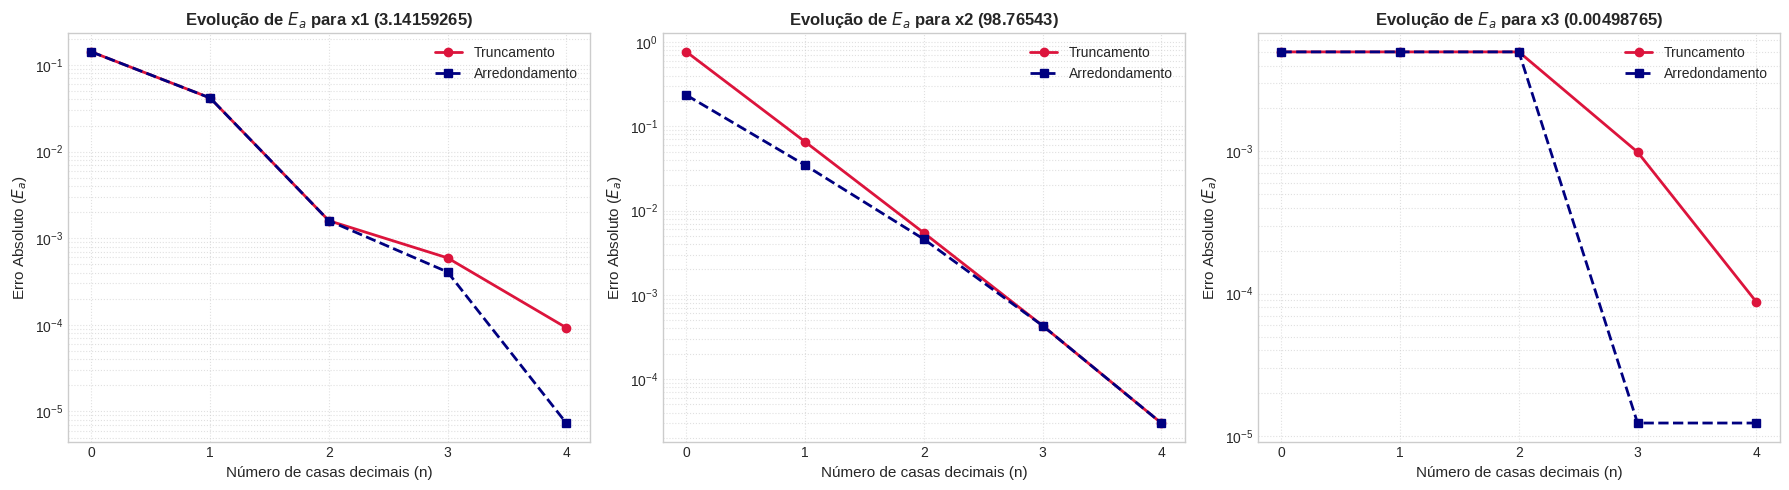

In [6]:
# Cria a figura com dimensões adequadas
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, (nome_val, x_ref) in enumerate(valores_teste.items()):
    df_sub = df_resultados[df_resultados["Variável"] == nome_val]
    ax = axes[idx]

    # Plota os erros absolutos de truncamento e arredondamento
    ax.plot(df_sub["n"], df_sub["Ea_trunc"], marker='o', linewidth=2, label="Truncamento", color="crimson")
    ax.plot(df_sub["n"], df_sub["Ea_round"], marker='s', linestyle='--', linewidth=2, label="Arredondamento", color="navy")

    # Configura o eixo y em escala logarítmica
    ax.set_yscale('log')

    # Identificação dos eixos e títulos
    ax.set_xlabel("Número de casas decimais (n)", fontsize=11)
    ax.set_ylabel("Erro Absoluto ($E_a$)", fontsize=11)
    ax.set_title(f"Evolução de $E_a$ para {nome_val}", fontsize=12, fontweight="bold")
    ax.set_xticks(casas_n)
    ax.legend()
    ax.grid(True, which="both", ls=":", alpha=0.6)

plt.tight_layout()
plt.show()

#### 4° Passo:
  Pergunta: Arredondar sempre gera erro menor ou igual ao truncamento?
  
  Resposta: Sim, o arredondamento sempre produz um erro menor ou igual ao truncamento. Essa propriedade decorre diretamente do critério de cada operação, pois enquanto o truncamento apenas descarta os dígitos a partir da casa $n+1$, o arredondamento escolhe o valor com $n$ casas mais próximo do número original, realizando a substituição conforme a norma adotada. Com isso, o limitante superior do erro absoluto no arredondamento é de $\frac{1}{2} \times 10^{-n}$, ao passo que no truncamento esse erro pode atingir até $10^{-n}$.

  Essa relação fica evidente em dois cenários:

  Os erros iguais ($E_{a,\text{round}} = E_{a,\text{trunc}}$) ocorrem sempre que o primeiro algarismo descartado é menor que 5. Por exemplo, para $x_1 = 3{,}14159265$ com $n=2$, o primeiro dígito descartado é 1; ambas as aproximações resultam em $3{,}14$, com o mesmo erro absoluto ($E_a \approx 0{,}00159$).  

  O erro estritamente menor no arredondamento ($E_{a,\text{round}} < E_{a,\text{trunc}}$) ocorre quando o primeiro algarismo descartado é maior ou igual a 5. Para $x_1$ com $n=3$, o dígito descartado é 5; o truncamento fornece $3{,}141$ ($E_a \approx 5{,}93 \times 10^{-4}$), enquanto o arredondamento fornece $3{,}142$ ($E_a \approx 4{,}07 \times 10^{-4}$).  

## Parte B - Medidas de Pressão Arterial

Medidas consecutivas de pressão arterial sistólica, em mmHg:

121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5.

(Média calculada com todos os algarismos disponíveis)

#### B.1 - Representação das Medidas:



In [7]:
import numpy as np
import pandas as pd

# Dados originais de pressão arterial sistólica (mmHg)
dados_originais = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

# 1. Dados arredondados para o inteiro mais próximo
dados_arredondados = np.round(dados_originais)

# 2. Dados truncados para números inteiros (mantendo a representação float/int sem arredondamento)
dados_truncados = np.array([float(int(x)) for x in dados_originais])

# Dicionário com as séries solicitadas
series = {
    "Originais (Referência)": dados_originais,
    "Arredondados (Inteiros)": dados_arredondados,
    "Truncados (Inteiros)": dados_truncados
}

# Média de referência exata com todos os algarismos disponíveis
media_referencia = np.mean(dados_originais)

resumo_estatistico = []

for nome, serie in series.items():
    media = np.mean(serie)
    minimo = np.min(serie)
    maximo = np.max(serie)
    amplitude = maximo - minimo
    # Desvio-padrão amostral (ddof=1)
    desvio_padrao = np.std(serie, ddof=1)

    # Cálculo dos erros em relação à média de referência
    erro_abs = abs(media_referencia - media)
    erro_rel = erro_abs / abs(media_referencia)
    erro_perc = 100.0 * erro_rel

    resumo_estatistico.append({
        "Série": nome,
        "Média (mmHg)": media,
        "Mínimo (mmHg)": minimo,
        "Máximo (mmHg)": maximo,
        "Amplitude (mmHg)": amplitude,
        "Desvio-Padrão (mmHg)": desvio_padrao,
        "Ea da Média (mmHg)": erro_abs,
        "Er da Média": erro_rel,
        "E% da Média (%)": erro_perc
    })

# DataFrame com precisão numérica completa (sem formatação limitante)
pd.reset_option('display.float_format')
df_b1 = pd.DataFrame(resumo_estatistico)

# Exibe a tabela completa com todos os dígitos de ponto flutuante
display(df_b1)

,Série,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-Padrão (mmHg),Ea da Média (mmHg),Er da Média,E% da Média (%)
0,Originais (Referência),121.12,119.8,122.4,2.6,0.833733,0.00,0.000000,0.000000
1,Arredondados (Inteiros),121.10,120.0,122.0,2.0,0.875595,0.02,0.000165,0.016513
2,Truncados (Inteiros),120.70,119.0,122.0,3.0,0.948683,0.42,0.003468,0.346764


#### B.2 - Gráficos:

<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_731/1759315032.py:46: SyntaxWarning: invalid escape sequence '\%'
  axes[1, 0].set_title("3. Erro Percentual da Média ($E_{\%}$)", fontsize=12, fontweight="bold")


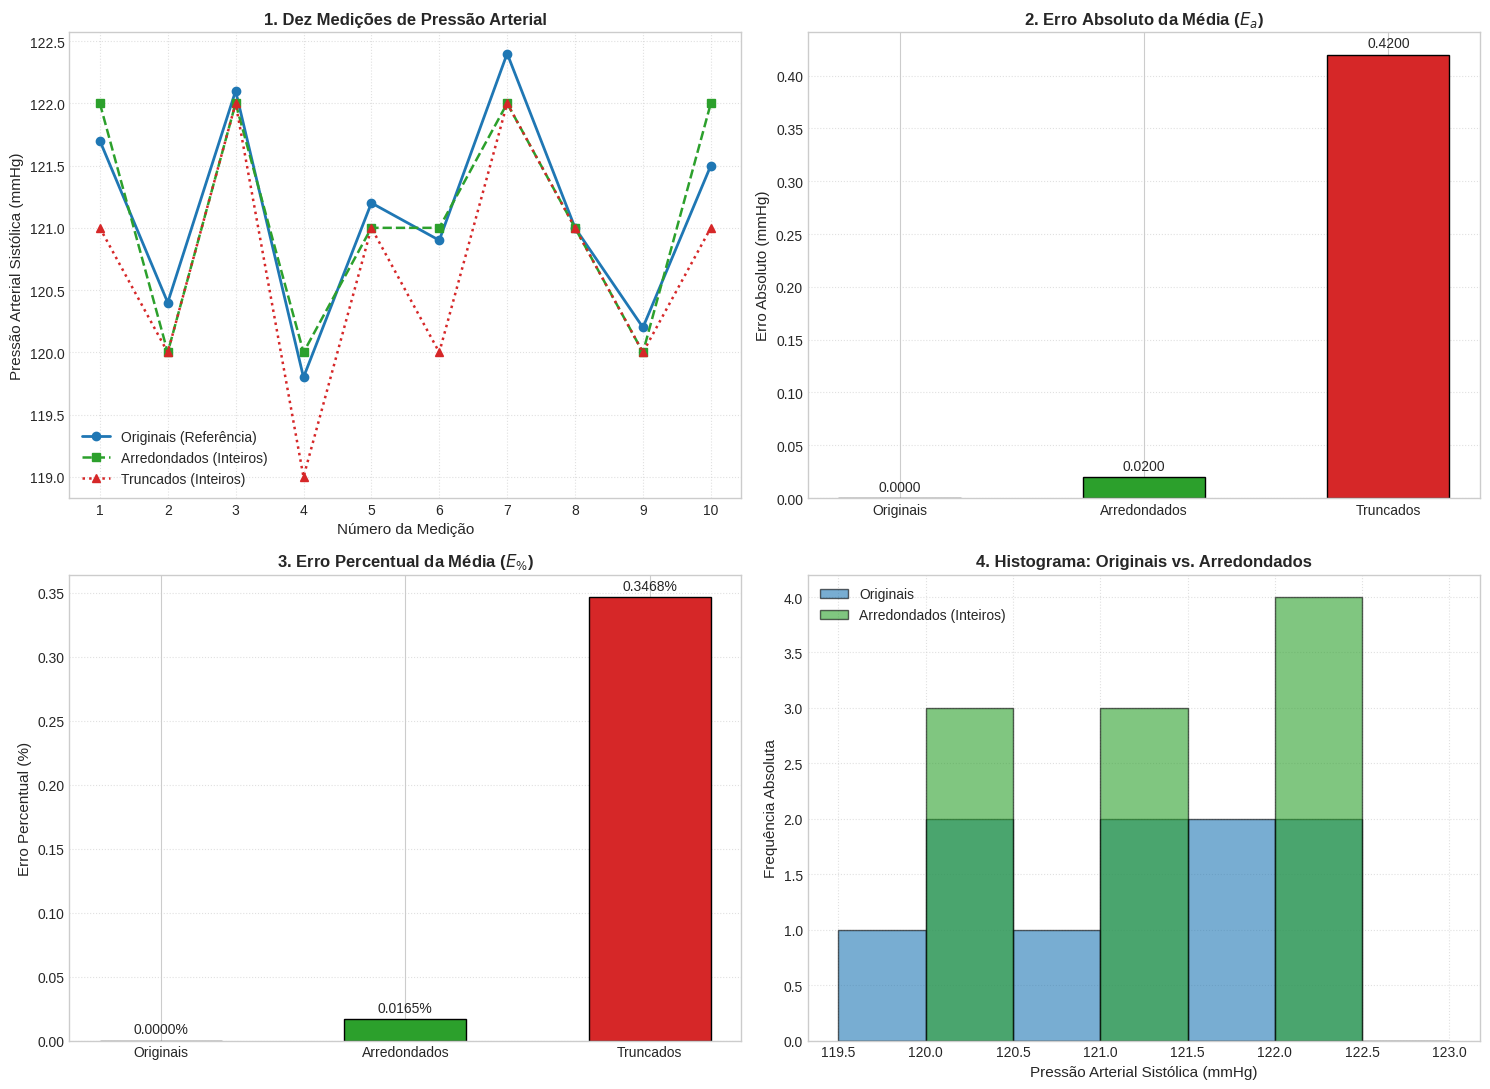

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Preparação dos dados e cálculos
# -------------------------------------------------------------
indices_medicoes = np.arange(1, len(dados_originais) + 1)

# Nomes e erros calculados no item B.1
nomes_series = ["Originais", "Arredondados", "Truncados"]
erros_abs_medias = [0.0, df_b1.loc[1, "Ea da Média (mmHg)"], df_b1.loc[2, "Ea da Média (mmHg)"]]
erros_perc_medias = [0.0, df_b1.loc[1, "E% da Média (%)"], df_b1.loc[2, "E% da Média (%)"]]

# -------------------------------------------------------------
# 2. Construção dos 4 Gráficos Obrigatórios
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Gráfico 1: As 10 medições comparando as três séries
axes[0, 0].plot(indices_medicoes, dados_originais, marker='o', linewidth=2, label="Originais (Referência)", color="#1f77b4")
axes[0, 0].plot(indices_medicoes, dados_arredondados, marker='s', linestyle='--', linewidth=1.8, label="Arredondados (Inteiros)", color="#2ca02c")
axes[0, 0].plot(indices_medicoes, dados_truncados, marker='^', linestyle=':', linewidth=1.8, label="Truncados (Inteiros)", color="#d62728")
axes[0, 0].set_title("1. Dez Medições de Pressão Arterial", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Número da Medição", fontsize=11)
axes[0, 0].set_ylabel("Pressão Arterial Sistólica (mmHg)", fontsize=11)
axes[0, 0].set_xticks(indices_medicoes)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 2: Barras dos Erros Absolutos das Médias
cores = ["#1f77b4", "#2ca02c", "#d62728"]
barras_ea = axes[0, 1].bar(nomes_series, erros_abs_medias, color=cores, width=0.5, edgecolor="black")
axes[0, 1].set_title("2. Erro Absoluto da Média ($E_a$)", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Erro Absoluto (mmHg)", fontsize=11)
axes[0, 1].grid(True, linestyle=":", alpha=0.6, axis="y")
# Rótulos de dados sobre as barras
for barra in barras_ea:
    altura = barra.get_height()
    axes[0, 1].annotate(f'{altura:.4f}',
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

# Gráfico 3: Barras dos Erros Percentuais das Médias
barras_ep = axes[1, 0].bar(nomes_series, erros_perc_medias, color=cores, width=0.5, edgecolor="black")
axes[1, 0].set_title("3. Erro Percentual da Média ($E_{\%}$)", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Erro Percentual (%)", fontsize=11)
axes[1, 0].grid(True, linestyle=":", alpha=0.6, axis="y")
# Rótulos de dados sobre as barras
for barra in barras_ep:
    altura = barra.get_height()
    axes[1, 0].annotate(f'{altura:.4f}%',
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

# Gráfico 4: Histograma dos dados originais vs inteiros arredondados
bins = np.arange(119.5, 123.5, 0.5)
axes[1, 1].hist(dados_originais, bins=bins, alpha=0.6, label="Originais", color="#1f77b4", edgecolor="black")
axes[1, 1].hist(dados_arredondados, bins=bins, alpha=0.6, label="Arredondados (Inteiros)", color="#2ca02c", edgecolor="black")
axes[1, 1].set_title("4. Histograma: Originais vs. Arredondados", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Pressão Arterial Sistólica (mmHg)", fontsize=11)
axes[1, 1].set_ylabel("Frequência Absoluta", fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

* Análise da Representação Inteira sobre a Média e a Variabilidade Amostral

  Pergunta: A representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra?

  Resposta: A representação inteira entrega uma boa preservação da média, com mínimo impacto quando obtida por arredondamento, mas falha em manter a variabilidade da amostra.  No caso da média, o arredondamento mantém uma precisão satisfatória, pode-se notar através do erro percentual quase nulo ($E_{\%} \approx 0{,}0165\%$) e um erro absoluto de apenas $0{,}02\text{ mmHg}$. Por outro lado, o truncamento introduz um viés que subestima todos os valores, elevando o erro percentual da média para $0{,}3468\%$ ($E_a = 0{,}42\text{ mmHg}$).  Quanto à variabilidade, a discretização em inteiros é insuficiente. Por se tratar de uma amostra pequena ($N=10$) com variações sutis, o descarte dos decimais reduz a dispersão dos dados, observada na queda da amplitude amostral de $2{,}6\text{ mmHg}$ para $2{,}0\text{ mmHg}$, e do desvio-padrão amostral de $0{,}8025\text{ mmHg}$ para $0{,}7379\text{ mmHg}$.   

## Parte C - Vazão em um tubo de pequeno diâmetro:
Para um escoamento laminar idealizado, a relação de Hagen–Poiseuille:

Q =πr4∆p/8μL

(Adotando: r = 0,80 mm, L = 0,20 m, μ = 3,5 × 10−3 Pa s, ∆p = 1200 Pa)

#### C.1 - Precisão das variáveis:

In [9]:
import math
import numpy as np

def truncar(numero, casas):
    """
    Trunca um número na quantidade de casas decimais especificada.
    """
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

def calcular_erros(referencia, aproximacao):
    """
    Calcula os erros absoluto, relativo e percentual.
    """
    erro_abs = abs(referencia - aproximacao)

    if referencia == 0.0:
        erro_rel = np.nan
        erro_perc = np.nan
    else:
        erro_rel = erro_abs / abs(referencia)
        erro_perc = 100.0 * erro_rel

    return erro_abs, erro_rel, erro_perc

In [10]:
import math
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 1. Função da Vazão de Hagen-Poiseuille
# -------------------------------------------------------------
def calcular_vazao_poiseuille(r, L, mu, delta_p):
    """
    Calcula a vazão volumétrica Q (m^3/s) para escoamento laminar.
    r: raio em metros (m)
    L: comprimento em metros (m)
    mu: viscosidade dinâmica em Pa.s
    delta_p: diferença de pressão em Pa
    """
    return (math.pi * (r ** 4) * delta_p) / (8.0 * mu * L)

# -------------------------------------------------------------
# 2. Parâmetros de Referência (convertidos para o SI)
# -------------------------------------------------------------
# r = 0.80 mm = 0.80e-3 m, L = 0.20 m, mu = 3.5e-3 Pa.s, delta_p = 1200 Pa
r_ref = 0.80e-3
L_ref = 0.20
mu_ref = 3.5e-3
dp_ref = 1200.0

# Q de referência
Q_ref = calcular_vazao_poiseuille(r_ref, L_ref, mu_ref, dp_ref)

# -------------------------------------------------------------
# 3. Definição dos Cenários de Aproximação
# -------------------------------------------------------------
# r em mm = 0.80 -> 1 casa decimal: round(0.80, 1)=0.8, truncar(0.80, 1)=0.8
# (Para evidenciar o efeito numérico de 1 casa decimal, 0.8 mm = 0.8e-3 m)
r_round = round(0.80, 1) * 1e-3
r_trunc = truncar(0.80, 1) * 1e-3

# mu = 0.0035 Pa.s -> 3 casas decimais: round=0.004 Pa.s, trunc=0.003 Pa.s
mu_round = round(mu_ref, 3)
mu_trunc = truncar(mu_ref, 3)

# delta_p = 1200 Pa -> centenas: round(1200/100)*100 = 1200 Pa, trunc = 1200 Pa
dp_round = round(dp_ref, -2)
dp_trunc = truncar(dp_ref, -2)

cenarios = {
    "1. Referência": (r_ref, L_ref, mu_ref, dp_ref),
    "2. r arredondado (1 casa mm)": (r_round, L_ref, mu_ref, dp_ref),
    "2. r truncado (1 casa mm)": (r_trunc, L_ref, mu_ref, dp_ref),
    "3. mu arredondada (3 casas Pa.s)": (r_ref, L_ref, mu_round, dp_ref),
    "3. mu truncada (3 casas Pa.s)": (r_ref, L_ref, mu_trunc, dp_ref),
    "4. delta_p arredondada (centenas Pa)": (r_ref, L_ref, mu_ref, dp_round),
    "4. delta_p truncada (centenas Pa)": (r_ref, L_ref, mu_ref, dp_trunc),
    "5. Todas aproximações (Arredondamento)": (r_round, L_ref, mu_round, dp_round),
    "5. Todas aproximações (Truncamento)": (r_trunc, L_ref, mu_trunc, dp_trunc)
}

# -------------------------------------------------------------
# 4. Cálculo dos Resultados e Tabela
# -------------------------------------------------------------
tabela_c1 = []

for nome, (r_val, l_val, mu_val, dp_val) in cenarios.items():
    Q_calc = calcular_vazao_poiseuille(r_val, l_val, mu_val, dp_val)
    ea, er, ep = calcular_erros(Q_ref, Q_calc)

    tabela_c1.append({
        "Cenário": nome,
        "r (mm)": r_val * 1e3,
        "mu (Pa.s)": mu_val,
        "delta_p (Pa)": dp_val,
        "Q (m³/s)": Q_calc,
        "Ea (m³/s)": ea,
        "Er": er,
        "E% (%)": ep
    })

df_c1 = pd.DataFrame(tabela_c1)
display(df_c1)

,Cenário,r (mm),mu (Pa.s),delta_p (Pa),Q (m³/s),Ea (m³/s),Er,E% (%)
0,1. Referência,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
1,2. r arredondado (1 casa mm),0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
2,2. r truncado (1 casa mm),0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
3,3. mu arredondada (3 casas Pa.s),0.8,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
4,3. mu truncada (3 casas Pa.s),0.8,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667
5,4. delta_p arredondada (centenas Pa),0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
6,4. delta_p truncada (centenas Pa),0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
7,5. Todas aproximações (Arredondamento),0.8,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
8,5. Todas aproximações (Truncamento),0.8,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667


#### C.2 - Sensibilidade:

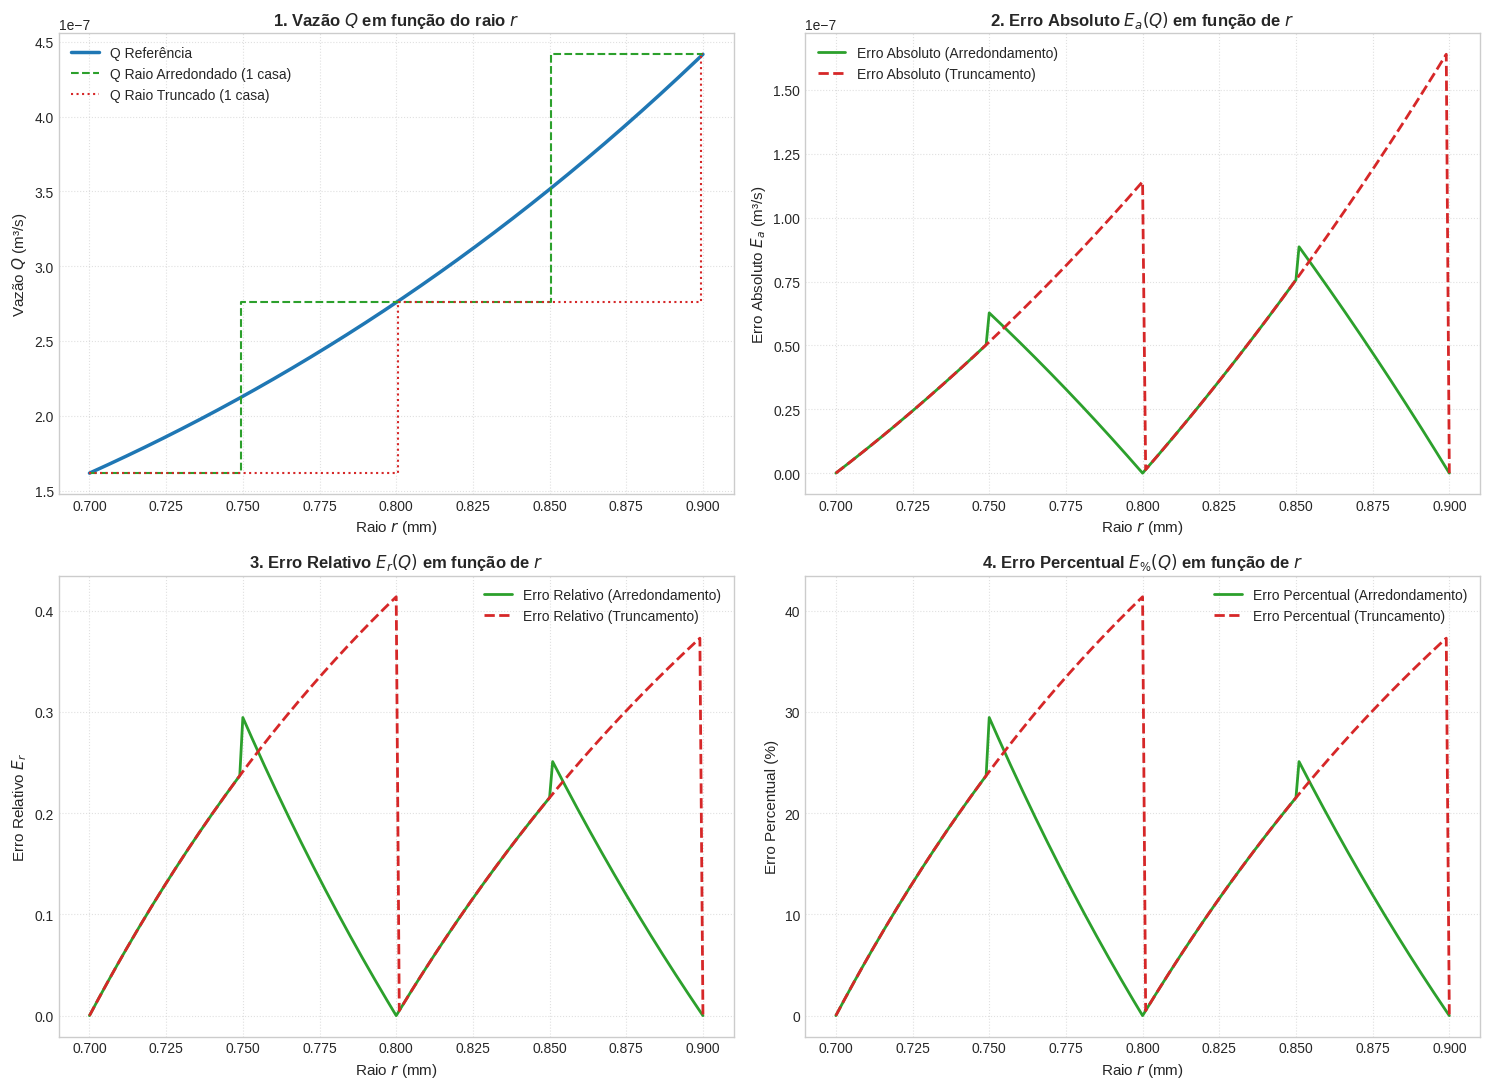

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Varredura do Raio
# -------------------------------------------------------------
# Cria 201 pontos de raio entre 0.70 mm e 0.90 mm
r_mm_array = np.linspace(0.70, 0.90, 201)
r_m_array = r_mm_array * 1e-3

# Vetores para armazenar as vazões
Q_ref_array = np.array([calcular_vazao_poiseuille(r, L_ref, mu_ref, dp_ref) for r in r_m_array])

# Raio arredondado e truncado para 1 casa decimal em mm
r_mm_round = np.array([round(val, 1) for val in r_mm_array])
r_mm_trunc = np.array([truncar(val, 1) for val in r_mm_array])

Q_round_array = np.array([calcular_vazao_poiseuille(r * 1e-3, L_ref, mu_ref, dp_ref) for r in r_mm_round])
Q_trunc_array = np.array([calcular_vazao_poiseuille(r * 1e-3, L_ref, mu_ref, dp_ref) for r in r_mm_trunc])

# -------------------------------------------------------------
# 2. Cálculo dos Erros de Q em Função de r
# -------------------------------------------------------------
Ea_round = np.abs(Q_ref_array - Q_round_array)
Ea_trunc = np.abs(Q_ref_array - Q_trunc_array)

Er_round = Ea_round / np.abs(Q_ref_array)
Er_trunc = Ea_trunc / np.abs(Q_ref_array)

Ep_round = 100.0 * Er_round
Ep_trunc = 100.0 * Er_trunc

# -------------------------------------------------------------
# 3. Geração dos 4 Gráficos Solicitados (com raw strings r"...")
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Gráfico 1: Q em função de r
axes[0, 0].plot(r_mm_array, Q_ref_array, label="Q Referência", color="#1f77b4", linewidth=2.5)
axes[0, 0].step(r_mm_array, Q_round_array, label="Q Raio Arredondado (1 casa)", color="#2ca02c", linestyle="--", where="mid")
axes[0, 0].step(r_mm_array, Q_trunc_array, label="Q Raio Truncado (1 casa)", color="#d62728", linestyle=":", where="mid")
axes[0, 0].set_title(r"1. Vazão $Q$ em função do raio $r$", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel(r"Raio $r$ (mm)", fontsize=11)
axes[0, 0].set_ylabel(r"Vazão $Q$ (m³/s)", fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 2: Erro Absoluto de Q em função de r
axes[0, 1].plot(r_mm_array, Ea_round, label="Erro Absoluto (Arredondamento)", color="#2ca02c", linewidth=2)
axes[0, 1].plot(r_mm_array, Ea_trunc, label="Erro Absoluto (Truncamento)", color="#d62728", linestyle="--", linewidth=2)
axes[0, 1].set_title(r"2. Erro Absoluto $E_a(Q)$ em função de $r$", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel(r"Raio $r$ (mm)", fontsize=11)
axes[0, 1].set_ylabel(r"Erro Absoluto $E_a$ (m³/s)", fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# Gráfico 3: Erro Relativo de Q em função de r
axes[1, 0].plot(r_mm_array, Er_round, label="Erro Relativo (Arredondamento)", color="#2ca02c", linewidth=2)
axes[1, 0].plot(r_mm_array, Er_trunc, label="Erro Relativo (Truncamento)", color="#d62728", linestyle="--", linewidth=2)
axes[1, 0].set_title(r"3. Erro Relativo $E_r(Q)$ em função de $r$", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel(r"Raio $r$ (mm)", fontsize=11)
axes[1, 0].set_ylabel(r"Erro Relativo $E_r$", fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 4: Erro Percentual de Q em função de r
axes[1, 1].plot(r_mm_array, Ep_round, label="Erro Percentual (Arredondamento)", color="#2ca02c", linewidth=2)
axes[1, 1].plot(r_mm_array, Ep_trunc, label="Erro Percentual (Truncamento)", color="#d62728", linestyle="--", linewidth=2)
axes[1, 1].set_title(r"4. Erro Percentual $E_{\%}(Q)$ em função de $r$", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel(r"Raio $r$ (mm)", fontsize=11)
axes[1, 1].set_ylabel("Erro Percentual (%)", fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

O erro no raio é fortemente amplificado na vazão devido à relação quártica estabelecida pela lei de Hagen-Poiseuille, na qual a vazão $Q$ é diretamente proporcional à quarta potência do raio ($Q \propto r^4$).  Pela propagação de incertezas em funções potência ($y = x^n$), a aproximação linear estabelece que o erro relativo da vazão é o quádruplo do erro relativo no raio:  $$\frac{\vert{}\Delta Q\vert{}}{Q} \approx 4\frac{\vert{}\Delta r\vert{}}{r}$$ Desse modo, significa que qualquer variação relativa introduzida na medição ou aproximação do raio é multiplicada por um fator aproximado de 4 no cálculo da vazão.




## Parte D - Escoamento em um nanocateter:
Considerando um modelo didático de nanocateter cilíndrico:

r = 50 nm, L = 10 μm, μ = 3,5 × 10−3 Pa s, ∆p = 5000 Pa.

(Usando novamente Hagen–Poiseuille para calcular Q)

#### D.1 - Erro geométrico:

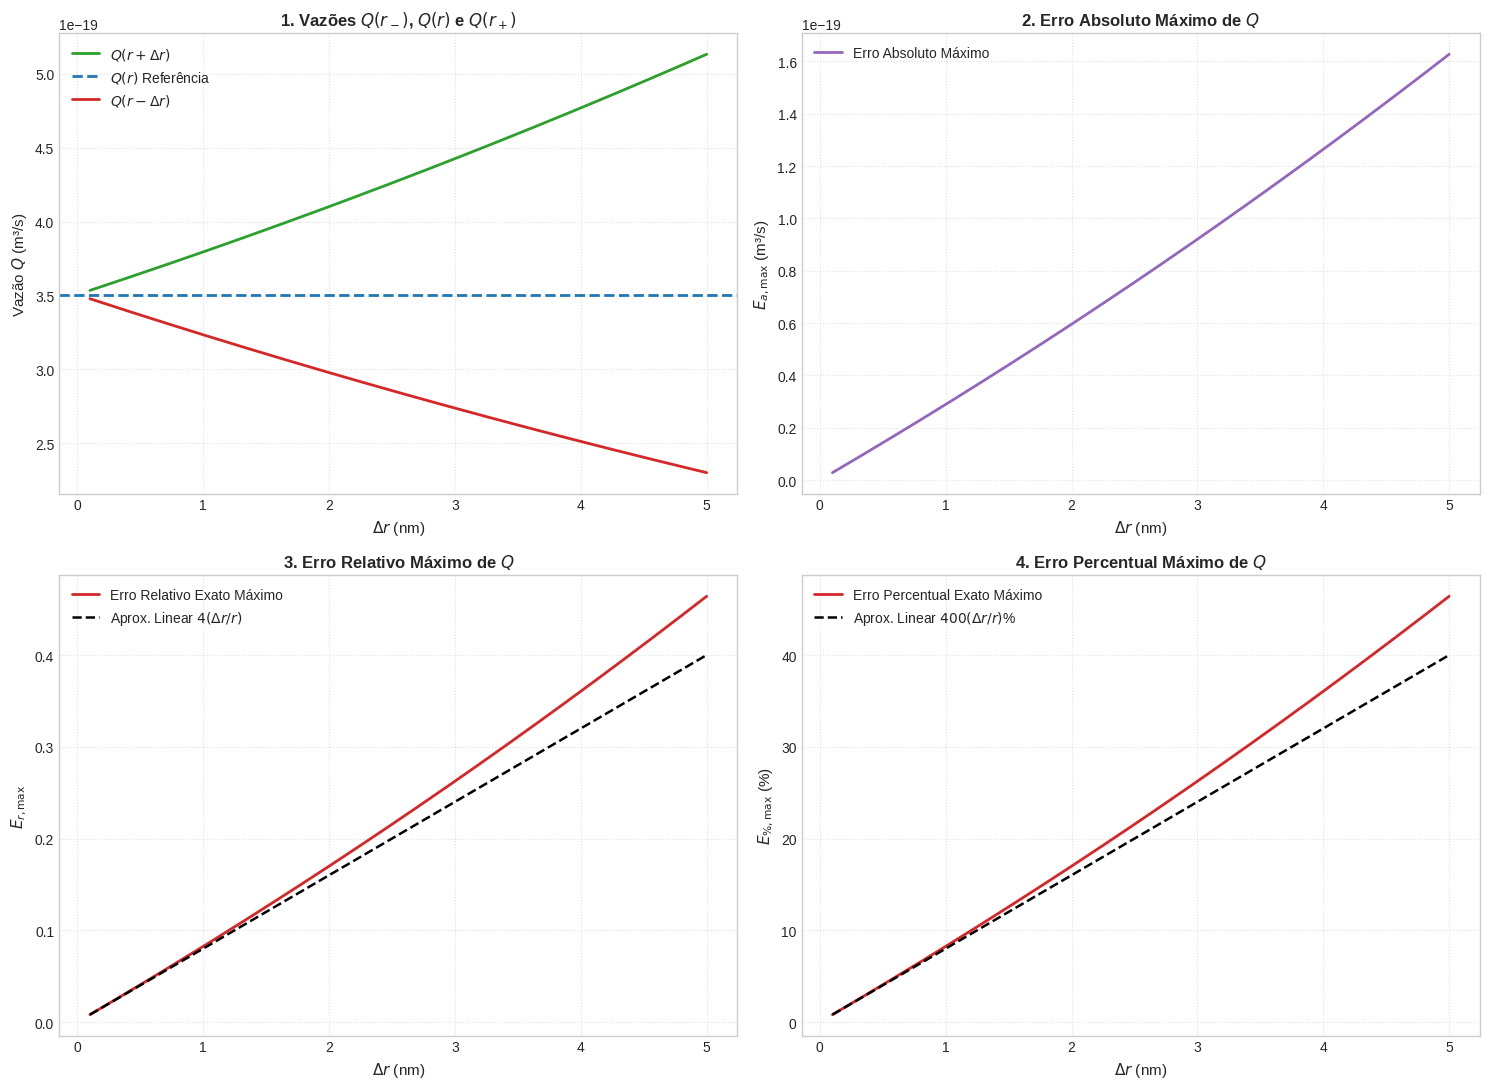

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do nanocateter no SI
r_nano = 50.0e-9       # 50 nm em metros
L_nano = 10.0e-6       # 10 µm em metros
mu_nano = 3.5e-3       # 3.5e-3 Pa.s
dp_nano = 5000.0       # 5000 Pa

# Vazão de referência Q(r)
Q_nano_ref = calcular_vazao_poiseuille(r_nano, L_nano, mu_nano, dp_nano)

# Variações de raio Delta r: de 0.1 nm a 5.0 nm (50 pontos)
# Aumentando para 300 pontos para suavizar perfeitamente as curvas
delta_r_nm = np.linspace(0.1, 5.0, 1000)
delta_r_m = delta_r_nm * 1e-9

r_menos = r_nano - delta_r_m
r_mais = r_nano + delta_r_m

# Vazões correspondentes
Q_menos = np.array([calcular_vazao_poiseuille(r, L_nano, mu_nano, dp_nano) for r in r_menos])
Q_mais = np.array([calcular_vazao_poiseuille(r, L_nano, mu_nano, dp_nano) for r in r_mais])

# Erros absolutos em relação a Q(r)
Ea_menos = np.abs(Q_nano_ref - Q_menos)
Ea_mais = np.abs(Q_nano_ref - Q_mais)
Ea_max = np.maximum(Ea_menos, Ea_mais)

# Erros relativos e percentuais máximos
Er_max = Ea_max / Q_nano_ref
Ep_max = 100.0 * Er_max

# Aproximação linear teórica: Delta Q / Q ≈ 4 * (Delta r / r)
aprox_linear_rel = 4.0 * (delta_r_m / r_nano)
aprox_linear_perc = 100.0 * aprox_linear_rel

# -------------------------------------------------------------
# Gráficos de D.1
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Gráfico 1: Vazões Q(r-), Q(r) e Q(r+)
axes[0, 0].plot(delta_r_nm, Q_mais, label=r"$Q(r + \Delta r)$", color="#2ca02c", linewidth=2)
axes[0, 0].axhline(Q_nano_ref, label=r"$Q(r)$ Referência", color="#1f77b4", linestyle="--", linewidth=2)
axes[0, 0].plot(delta_r_nm, Q_menos, label=r"$Q(r - \Delta r)$", color="#d62728", linewidth=2)
axes[0, 0].set_title(r"1. Vazões $Q(r_-)$, $Q(r)$ e $Q(r_+)$", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel(r"$\Delta r$ (nm)", fontsize=11)
axes[0, 0].set_ylabel(r"Vazão $Q$ (m³/s)", fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 2: Erro Absoluto Máximo
axes[0, 1].plot(delta_r_nm, Ea_max, color="#9467bd", linewidth=2, label="Erro Absoluto Máximo")
axes[0, 1].set_title(r"2. Erro Absoluto Máximo de $Q$", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel(r"$\Delta r$ (nm)", fontsize=11)
axes[0, 1].set_ylabel(r"$E_{a,\max}$ (m³/s)", fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# Gráfico 3: Erro Relativo Máximo vs Aproximação Linear
axes[1, 0].plot(delta_r_nm, Er_max, label="Erro Relativo Exato Máximo", color="#d62728", linewidth=2)
axes[1, 0].plot(delta_r_nm, aprox_linear_rel, "--", label=r"Aprox. Linear $4(\Delta r / r)$", color="black", linewidth=1.8)
axes[1, 0].set_title(r"3. Erro Relativo Máximo de $Q$", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel(r"$\Delta r$ (nm)", fontsize=11)
axes[1, 0].set_ylabel(r"$E_{r,\max}$", fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 4: Erro Percentual Máximo vs Aproximação Linear
axes[1, 1].plot(delta_r_nm, Ep_max, label="Erro Percentual Exato Máximo", color="#d62728", linewidth=2)
axes[1, 1].plot(delta_r_nm, aprox_linear_perc, "--", label=r"Aprox. Linear $400(\Delta r / r)$%", color="black", linewidth=1.8)
axes[1, 1].set_title(r"4. Erro Percentual Máximo de $Q$", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel(r"$\Delta r$ (nm)", fontsize=11)
axes[1, 1].set_ylabel(r"$E_{\%,\max}$ (%)", fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

#### D.2 - Precisão Computacional:

In [13]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 1. Comparação Direta: float32 vs float64
# -------------------------------------------------------------
# Entradas em float32
r_f32 = np.float32(50.0e-9)
L_f32 = np.float32(10.0e-6)
mu_f32 = np.float32(3.5e-3)
dp_f32 = np.float32(5000.0)
pi_f32 = np.float32(np.pi)

r4_f32 = r_f32 ** 4
Q_f32 = (pi_f32 * r4_f32 * dp_f32) / (np.float32(8.0) * mu_f32 * L_f32)

# Entradas em float64
r_f64 = np.float64(50.0e-9)
L_f64 = np.float64(10.0e-6)
mu_f64 = np.float64(3.5e-3)
dp_f64 = np.float64(5000.0)
pi_f64 = np.float64(np.pi)

r4_f64 = r_f64 ** 4
Q_f64 = (pi_f64 * r4_f64 * dp_f64) / (np.float64(8.0) * mu_f64 * L_f64)

dif_abs_Q = abs(Q_f64 - np.float64(Q_f32))
dif_rel_Q = dif_abs_Q / abs(Q_f64)

eps_f32 = np.finfo(np.float32).eps
eps_f64 = np.finfo(np.float64).eps

print("=== COMPARAÇÃO DE PRECISÃO COMPUTACIONAL ===")
print(f"r^4 (float32): {r4_f32:.16e} | r^4 (float64): {r4_f64:.16e}")
print(f"Q   (float32): {Q_f32:.16e} | Q   (float64): {Q_f64:.16e}")
print(f"Diferença Absoluta em Q: {dif_abs_Q:.16e} m³/s")
print(f"Diferença Relativa em Q: {dif_rel_Q:.16e}")
print(f"Epsilon float32: {eps_f32:.16e} | Epsilon float64: {eps_f64:.16e}\n")

# -------------------------------------------------------------
# 2. Teste de Perda de Significância por Cancelamento Numérico
# -------------------------------------------------------------

# Valores da razão Delta r / r cobrindo desde desvios macro até além da precisão de máquina
razoes_dr = [1e-1, 1e-3, 1e-6, 1e-10, 1e-14, 1e-16, 1e-18]

dados_tabela = []

for dr_r in razoes_dr:
    dr = dr_r * r_f64

    # 1. Forma Direta: depende do cálculo e subtração das vazões
    Q_perturbado = calcular_vazao_poiseuille(r_f64 + dr, L_f64, mu_f64, dp_f64)
    delta_1 = (Q_perturbado - Q_f64) / Q_f64

    # 2. Forma Analítica: relação adimensional direta
    delta_2 = ((1.0 + dr_r) ** 4) - 1.0

    # Diagnóstico da estabilidade
    if dr_r >= 1e-6:
        diagnostico = "Alta precisão (ambas concordam)"
    elif dr_r >= 1e-14:
        diagnostico = "Início de perda de significância"
    else:
        diagnostico = "Cancelamento catastrófico (resultado nulo)"

    dados_tabela.append({
        "Δr / r": f"{dr_r:.1e}",
        "delta_1 (Via Vazão Q)": f"{delta_1:.8e}",
        "delta_2 ((1+x)⁴ - 1)": f"{delta_2:.8e}",
        "Diferença |d1 - d2|": f"{abs(delta_1 - delta_2):.4e}",
        "Diagnóstico Numérico": diagnostico
    })

# Criação do DataFrame legível
df_cancelamento_claro = pd.DataFrame(dados_tabela)

# Exibição da tabela formatada
display(df_cancelamento_claro)

=== COMPARAÇÃO DE PRECISÃO COMPUTACIONAL ===
r^4 (float32): 6.2500003959774226e-30 | r^4 (float64): 6.2499999999999991e-30
Q   (float32): 3.5062423237442339e-19 | Q   (float64): 3.5062418008814650e-19
Diferença Absoluta em Q: 5.2286276891843277e-26 m³/s
Diferença Relativa em Q: 1.4912342006389455e-07
Epsilon float32: 1.1920928955078125e-07 | Epsilon float64: 2.2204460492503131e-16



,Δr / r,delta_1 (Via Vazão Q),delta_2 ((1+x)⁴ - 1),Diferença |d1 - d2|,Diagnóstico Numérico
0,1.0e-01,4.64100000e-01,4.64100000e-01,8.3267e-16,Alta precisão (ambas concordam)
1,1.0e-03,4.00600400e-03,4.00600400e-03,2.2378e-16,Alta precisão (ambas concordam)
2,1.0e-06,4.00000600e-06,4.00000600e-06,2.6112e-16,Alta precisão (ambas concordam)
3,1.0e-10,4.00000038e-10,4.00000033e-10,4.5194e-18,Início de perda de significância
4,1.0e-14,4.02352081e-14,3.99680289e-14,2.6718e-16,Início de perda de significância
5,1.0e-16,4.11964588e-16,0.00000000e+00,4.1196e-16,Cancelamento catastrófico (resultado nulo)
6,1.0e-18,0.00000000e+00,0.00000000e+00,0.0000e+00,Cancelamento catastrófico (resultado nulo)


Fenômeno Físico: Razão Superfície/Volume e Limitações do Modelo

  A redução da escala para dimensões nanométricas eleva drasticamente a razão superfície/volume ($2/r$), amplificando a sensibilidade do escoamento aos efeitos viscosos e de parede, pois, conforme demonstrado nos experimentos numéricos, uma variação ínfima no raio gera fortes discrepâncias na vazão devido à dependência quártica ($Q \propto r^4$), enquanto que a representação computacional atinge o limite de máquina, o que por sua vez ocasiona perda de significância por cancelamento numérico (cancelamento catastrófico). Portanto, esse comportamento evidencia que um resultado com alta precisão aritmética (múltiplas casas decimais em float64) não assegura a validade física da solução.

## Parte E - Síntese Visual:


Quadro síntese exportado com sucesso: 'quadro_sintese_resultados.png'


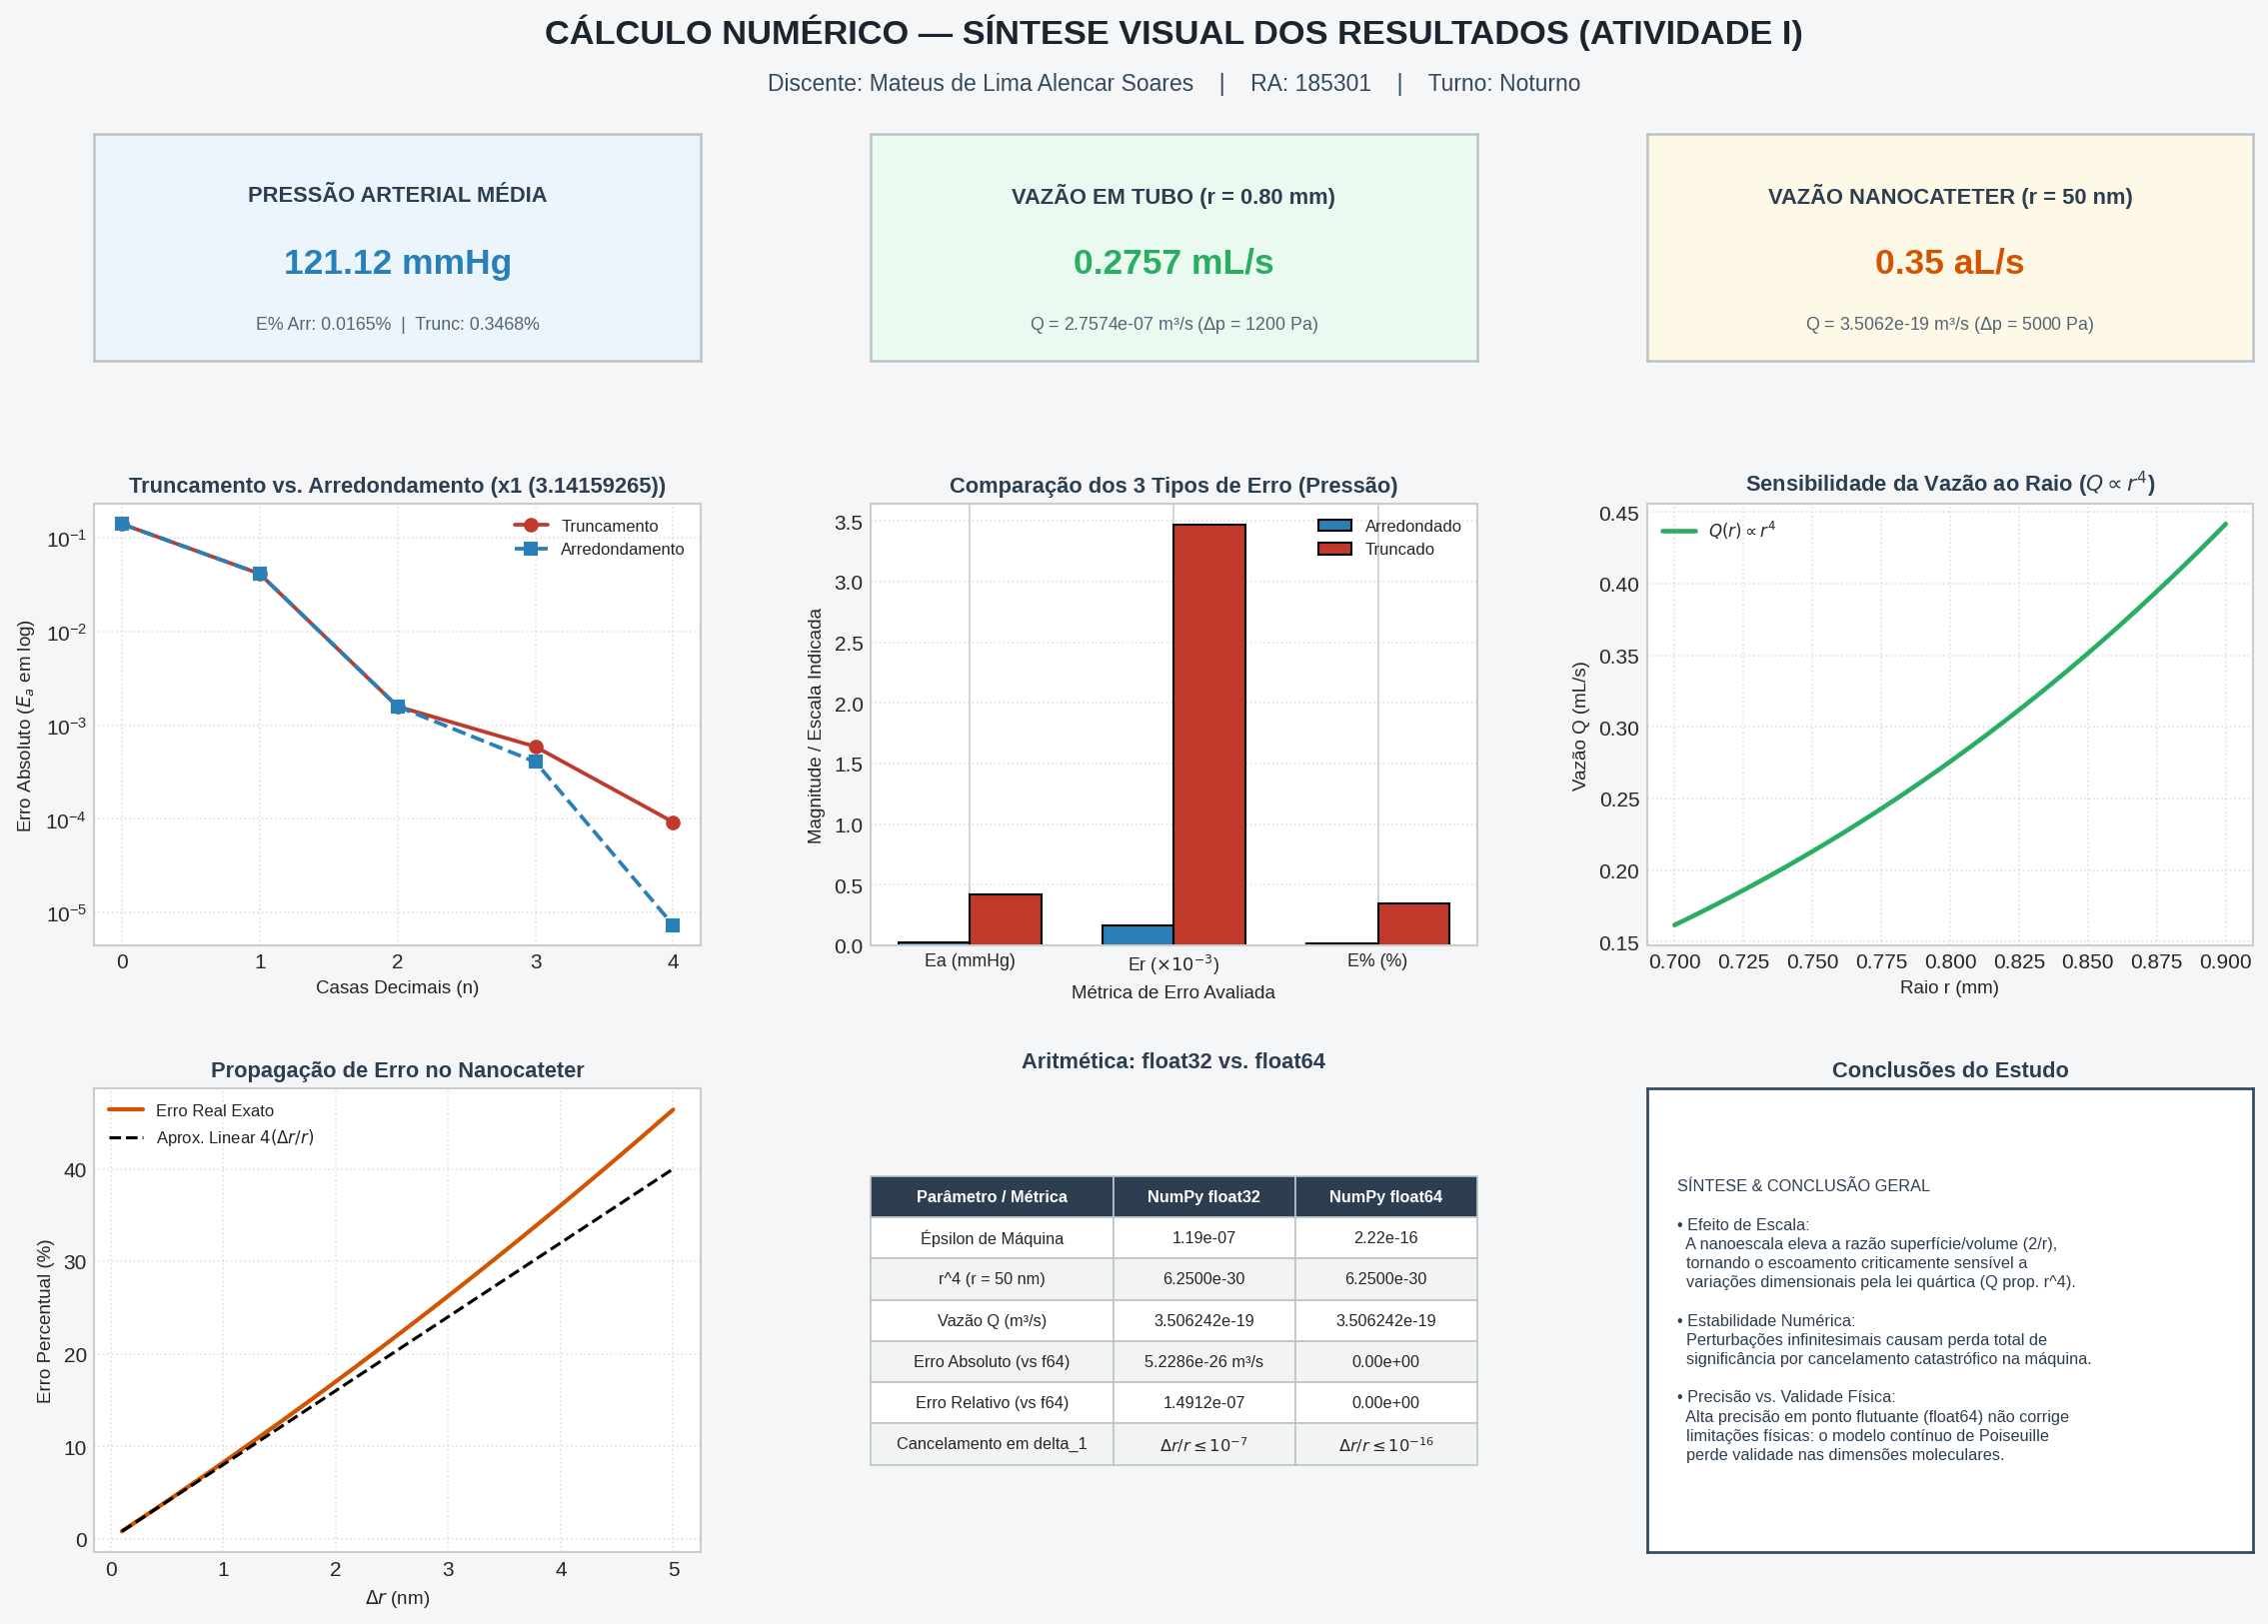

In [16]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -----------------------------------------------------------------------------
# 0. Funções e Recálculos Defensivos de Suporte (Autocontido)
# -----------------------------------------------------------------------------
def truncar_val(num, n):
    fat = 10 ** n
    return math.trunc(num * fat) / fat

def calcular_vazao_poiseuille(r, L, mu, dp):
    return (math.pi * (r ** 4) * dp) / (8.0 * mu * L)

# Dados de apoio caso a tabela do bloco A não esteja na memória
if "tabela" not in globals():
    x1_ref = 3.14159265
    dados_a = []
    for n in range(5):
        xt = truncar_val(x1_ref, n)
        xr = round(x1_ref, n)
        dados_a.append({"valor": "x1 (3.14159265)", "n": n, "metodo": "truncamento", "Ea": abs(x1_ref - xt)})
        dados_a.append({"valor": "x1 (3.14159265)", "n": n, "metodo": "arredondamento", "Ea": abs(x1_ref - xr)})
    tabela = pd.DataFrame(dados_a)

# Parâmetros de Referência Globais
# 1. Pressão Arterial (Parte B)
p_dados = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
p_med_ref = np.mean(p_dados)
p_med_arr = np.mean(np.round(p_dados))
p_med_tru = np.mean(np.array([float(int(v)) for v in p_dados]))

ea_p_arr, er_p_arr, ep_p_arr = abs(p_med_ref - p_med_arr), abs(p_med_ref - p_med_arr) / p_med_ref, 100.0 * (abs(p_med_ref - p_med_arr) / p_med_ref)
ea_p_tru, er_p_tru, ep_p_tru = abs(p_med_ref - p_med_tru), abs(p_med_ref - p_med_tru) / p_med_ref, 100.0 * (abs(p_med_ref - p_med_tru) / p_med_ref)

# 2. Tubo Macroscópico (Parte C)
r_macro, L_macro, mu_macro, dp_macro = 0.80e-3, 0.20, 3.5e-3, 1200.0
Q_macro_ref = calcular_vazao_poiseuille(r_macro, L_macro, mu_macro, dp_macro)

# 3. Nanocateter (Parte D)
r_nano, L_nano, mu_nano, dp_nano = 50.0e-9, 10.0e-6, 3.5e-3, 5000.0
Q_nano_ref = calcular_vazao_poiseuille(r_nano, L_nano, mu_nano, dp_nano)

# 4. Aritmética float32 vs float64 (Parte D.2)
eps_f32, eps_f64 = np.finfo(np.float32).eps, np.finfo(np.float64).eps
r4_f32, r4_f64 = np.float32(r_nano)**4, np.float64(r_nano)**4
Q_f32 = (np.float32(np.pi) * r4_f32 * np.float32(dp_nano)) / (np.float32(8.0) * np.float32(mu_nano) * np.float32(L_nano))
Q_f64 = (np.float64(np.pi) * r4_f64 * np.float64(dp_nano)) / (np.float64(8.0) * np.float64(mu_nano) * np.float64(L_nano))
dif_abs_Q = abs(Q_f64 - np.float64(Q_f32))
dif_rel_Q = dif_abs_Q / abs(Q_f64)

# -----------------------------------------------------------------------------
# 1. Configuração da Tela e Cabeçalho
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 11), dpi=150, facecolor="#f4f6f7")

# Título Principal do Relatório
fig.text(
    0.5, 0.970,
    "CÁLCULO NUMÉRICO — SÍNTESE VISUAL DOS RESULTADOS (ATIVIDADE I)",
    fontsize=16.5,
    fontweight="bold",
    color="#1a252f",
    ha="center"
)

# Espaço de Identificação do Aluno
NOME_ALUNO = "Mateus de Lima Alencar Soares"
RA_ALUNO   = "185301"
TURNO_ALUNO = "Noturno"   # Ex: Matutino, Vespertino, Noturno

fig.text(
    0.5, 0.942,
    f"Discente: {NOME_ALUNO}    |    RA: {RA_ALUNO}    |    Turno: {TURNO_ALUNO}",
    fontsize=11,
    fontweight="medium",
    color="#34495e",
    ha="center"
)

# Divisão em Blocos via GridSpec
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    height_ratios=[0.20, 0.39, 0.41],
    hspace=0.38,
    wspace=0.28,
    top=0.915,
    bottom=0.055,
    left=0.05,
    right=0.95
)

# -----------------------------------------------------------------------------
# BLOCO 1: Cartões Métricos Superiores (KPIs)
# -----------------------------------------------------------------------------
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])

for ax in [ax_kpi1, ax_kpi2, ax_kpi3]:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#bdc3c7")
        spine.set_linewidth(1.2)

# KPI 1: Pressão
ax_kpi1.set_facecolor("#ebf5fb")
ax_kpi1.text(0.5, 0.73, "PRESSÃO ARTERIAL MÉDIA", ha="center", va="center", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_kpi1.text(0.5, 0.43, f"{p_med_ref:.2f} mmHg", ha="center", va="center", fontsize=17, fontweight="bold", color="#2980b9")
ax_kpi1.text(0.5, 0.16, f"E% Arr: {ep_p_arr:.4f}%  |  Trunc: {ep_p_tru:.4f}%", ha="center", va="center", fontsize=8.5, color="#566573")

# KPI 2: Tubo Macroscópico
ax_kpi2.set_facecolor("#eafaf1")
ax_kpi2.text(0.5, 0.73, "VAZÃO EM TUBO (r = 0.80 mm)", ha="center", va="center", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_kpi2.text(0.5, 0.43, f"{Q_macro_ref*1e6:.4f} mL/s", ha="center", va="center", fontsize=17, fontweight="bold", color="#27ae60")
ax_kpi2.text(0.5, 0.16, rf"Q = {Q_macro_ref:.4e} m³/s ($\Delta$p = 1200 Pa)", ha="center", va="center", fontsize=8.5, color="#566573")

# KPI 3: Nanocateter
ax_kpi3.set_facecolor("#fef9e7")
ax_kpi3.text(0.5, 0.73, "VAZÃO NANOCATETER (r = 50 nm)", ha="center", va="center", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_kpi3.text(0.5, 0.43, f"{Q_nano_ref*1e18:.2f} aL/s", ha="center", va="center", fontsize=17, fontweight="bold", color="#d35400")
ax_kpi3.text(0.5, 0.16, rf"Q = {Q_nano_ref:.4e} m³/s ($\Delta$p = 5000 Pa)", ha="center", va="center", fontsize=8.5, color="#566573")

# -----------------------------------------------------------------------------
# BLOCO 2: Linha Intermediária (Erros Fundamentais & Sensibilidade Física)
# -----------------------------------------------------------------------------
# 2.1 Truncamento vs Arredondamento (Parte A)
primeiro_x = tabela["valor"].iloc[0]
df_t_trunc = tabela[(tabela["valor"] == primeiro_x) & (tabela["metodo"] == "truncamento")]
df_t_round = tabela[(tabela["valor"] == primeiro_x) & (tabela["metodo"] == "arredondamento")]

ax_parte_a = fig.add_subplot(gs[1, 0])
ax_parte_a.plot(df_t_trunc["n"], df_t_trunc["Ea"], marker="o", color="#c0392b", linewidth=1.8, label="Truncamento")
ax_parte_a.plot(df_t_round["n"], df_t_round["Ea"], marker="s", linestyle="--", color="#2980b9", linewidth=1.8, label="Arredondamento")
ax_parte_a.set_yscale("log")
ax_parte_a.set_title(rf"Truncamento vs. Arredondamento ({primeiro_x})", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_parte_a.set_xlabel("Casas Decimais (n)", fontsize=9.0)
ax_parte_a.set_ylabel(r"Erro Absoluto ($E_a$ em log)", fontsize=9.0)
ax_parte_a.set_xticks(sorted(tabela["n"].unique()))
ax_parte_a.legend(fontsize=8.0)
ax_parte_a.grid(True, linestyle=":", alpha=0.6)

# 2.2 Comparação dos 3 Tipos de Erro (Parte B)
ax_erros = fig.add_subplot(gs[1, 1])
categorias = ["Ea (mmHg)", r"Er ($\times 10^{-3}$)", "E% (%)"]
valores_arr = [ea_p_arr, er_p_arr * 1e3, ep_p_arr]
valores_tru = [ea_p_tru, er_p_tru * 1e3, ep_p_tru]

x_pos = np.arange(len(categorias))
largura = 0.35
ax_erros.bar(x_pos - largura/2, valores_arr, largura, label="Arredondado", color="#2980b9", edgecolor="black")
ax_erros.bar(x_pos + largura/2, valores_tru, largura, label="Truncado", color="#c0392b", edgecolor="black")
ax_erros.set_title("Comparação dos 3 Tipos de Erro (Pressão)", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_erros.set_xlabel("Métrica de Erro Avaliada", fontsize=9.0)
ax_erros.set_ylabel("Magnitude / Escala Indicada", fontsize=9.0)
ax_erros.set_xticks(x_pos)
ax_erros.set_xticklabels(categorias, fontsize=8.5)
ax_erros.legend(fontsize=8.0)
ax_erros.grid(True, linestyle=":", alpha=0.6, axis="y")

# 2.3 Sensibilidade Quártica Q(r) (Parte C)
ax_sensib = fig.add_subplot(gs[1, 2])
r_var_mm = np.linspace(0.70, 0.90, 150)
Q_var = [calcular_vazao_poiseuille(r*1e-3, L_macro, mu_macro, dp_macro)*1e6 for r in r_var_mm]
ax_sensib.plot(r_var_mm, Q_var, color="#27ae60", linewidth=2.2, label=r"$Q(r) \propto r^4$")
ax_sensib.set_title(r"Sensibilidade da Vazão ao Raio ($Q \propto r^4$)", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_sensib.set_xlabel("Raio r (mm)", fontsize=9.0)
ax_sensib.set_ylabel("Vazão Q (mL/s)", fontsize=9.0)
ax_sensib.legend(fontsize=8.0)
ax_sensib.grid(True, linestyle=":", alpha=0.6)

# -----------------------------------------------------------------------------
# BLOCO 3: Linha Inferior (Nanoescala, Aritmética Computacional e Conclusão)
# -----------------------------------------------------------------------------
# 3.1 Propagação de Erro no Nanocateter (Parte D.1)
ax_nano = fig.add_subplot(gs[2, 0])
dr_plot_nm = np.linspace(0.1, 5.0, 150)
dr_plot_m = dr_plot_nm * 1e-9

Q_menos_v = np.array([calcular_vazao_poiseuille(r_nano - dr, L_nano, mu_nano, dp_nano) for dr in dr_plot_m])
Q_mais_v = np.array([calcular_vazao_poiseuille(r_nano + dr, L_nano, mu_nano, dp_nano) for dr in dr_plot_m])
ep_max_plot = 100.0 * np.maximum(np.abs(Q_nano_ref - Q_menos_v), np.abs(Q_nano_ref - Q_mais_v)) / Q_nano_ref
aprox_lin_plot = 400.0 * (dr_plot_nm / 50.0)

ax_nano.plot(dr_plot_nm, ep_max_plot, color="#d35400", linewidth=2.0, label="Erro Real Exato")
ax_nano.plot(dr_plot_nm, aprox_lin_plot, "--", color="black", linewidth=1.5, label=r"Aprox. Linear $4(\Delta r/r)$")
ax_nano.set_title("Propagação de Erro no Nanocateter", fontsize=10.5, fontweight="bold", color="#2c3e50")
ax_nano.set_xlabel(r"$\Delta r$ (nm)", fontsize=9.0)
ax_nano.set_ylabel("Erro Percentual (%)", fontsize=9.0)
ax_nano.legend(fontsize=8.0)
ax_nano.grid(True, linestyle=":", alpha=0.6)

# 3.2 Tabela Aritmética float32 vs float64 (Parte D.2)
ax_precisao = fig.add_subplot(gs[2, 1])
ax_precisao.axis("off")
tabela_dados = [
    ["Parâmetro / Métrica", "NumPy float32", "NumPy float64"],
    ["Épsilon de Máquina", f"{eps_f32:.2e}", f"{eps_f64:.2e}"],
    ["r^4 (r = 50 nm)", f"{r4_f32:.4e}", f"{r4_f64:.4e}"],
    ["Vazão Q (m³/s)", f"{Q_f32:.6e}", f"{Q_f64:.6e}"],
    ["Erro Absoluto (vs f64)", f"{dif_abs_Q:.4e} m³/s", "0.00e+00"],
    ["Erro Relativo (vs f64)", f"{dif_rel_Q:.4e}", "0.00e+00"],
    ["Cancelamento em delta_1", r"$\Delta r/r \leq 10^{-7}$", r"$\Delta r/r \leq 10^{-16}$"]
]
tabela_plot = ax_precisao.table(
    cellText=tabela_dados,
    cellLoc="center",
    loc="center",
    colWidths=[0.40, 0.30, 0.30]
)
tabela_plot.auto_set_font_size(False)
tabela_plot.set_fontsize(7.8)
tabela_plot.scale(1.0, 1.65)

for (row, col), cell in tabela_plot.get_celld().items():
    cell.set_edgecolor("#bdc3c7")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f2f4f4")
    else:
        cell.set_facecolor("#ffffff")
ax_precisao.set_title("Aritmética: float32 vs. float64", fontsize=10.5, fontweight="bold", color="#2c3e50", pad=10)

# 3.3 Conclusão do Estudo (Parte D.3)
ax_conclusao = fig.add_subplot(gs[2, 2])
ax_conclusao.set_facecolor("#ffffff")
for spine in ax_conclusao.spines.values():
    spine.set_color("#34495e")
    spine.set_linewidth(1.3)
ax_conclusao.set_xticks([])
ax_conclusao.set_yticks([])

texto_conclusao = (
    "SÍNTESE & CONCLUSÃO GERAL\n\n"
    "• Efeito de Escala:\n"
    "  A nanoescala eleva a razão superfície/volume (2/r),\n"
    "  tornando o escoamento criticamente sensível a\n"
    "  variações dimensionais pela lei quártica (Q prop. r^4).\n\n"
    "• Estabilidade Numérica:\n"
    "  Perturbações infinitesimais causam perda total de\n"
    "  significância por cancelamento catastrófico na máquina.\n\n"
    "• Precisão vs. Validade Física:\n"
    "  Alta precisão em ponto flutuante (float64) não corrige\n"
    "  limitações físicas: o modelo contínuo de Poiseuille\n"
    "  perde validade nas dimensões moleculares."
)

ax_conclusao.text(
    0.05, 0.50,
    texto_conclusao,
    fontsize=7.8,
    color="#2c3e50",
    va="center",
    ha="left",
    linespacing=1.35
)
ax_conclusao.set_title("Conclusões do Estudo", fontsize=10.5, fontweight="bold", color="#2c3e50")

# -----------------------------------------------------------------------------
# 2. Salvamento em PNG de Alta Resolução (2400 x 1650 px)
# -----------------------------------------------------------------------------
nome_arquivo = "quadro_sintese_resultados.png"
plt.savefig(nome_arquivo, dpi=150, bbox_inches="tight")
print(f"Quadro síntese exportado com sucesso: '{nome_arquivo}'")
plt.show()

## GIF Demonstrativo:

GIF animado gerado com sucesso: 'nanocateter_animacao.gif' (60 quadros, 20 FPS)


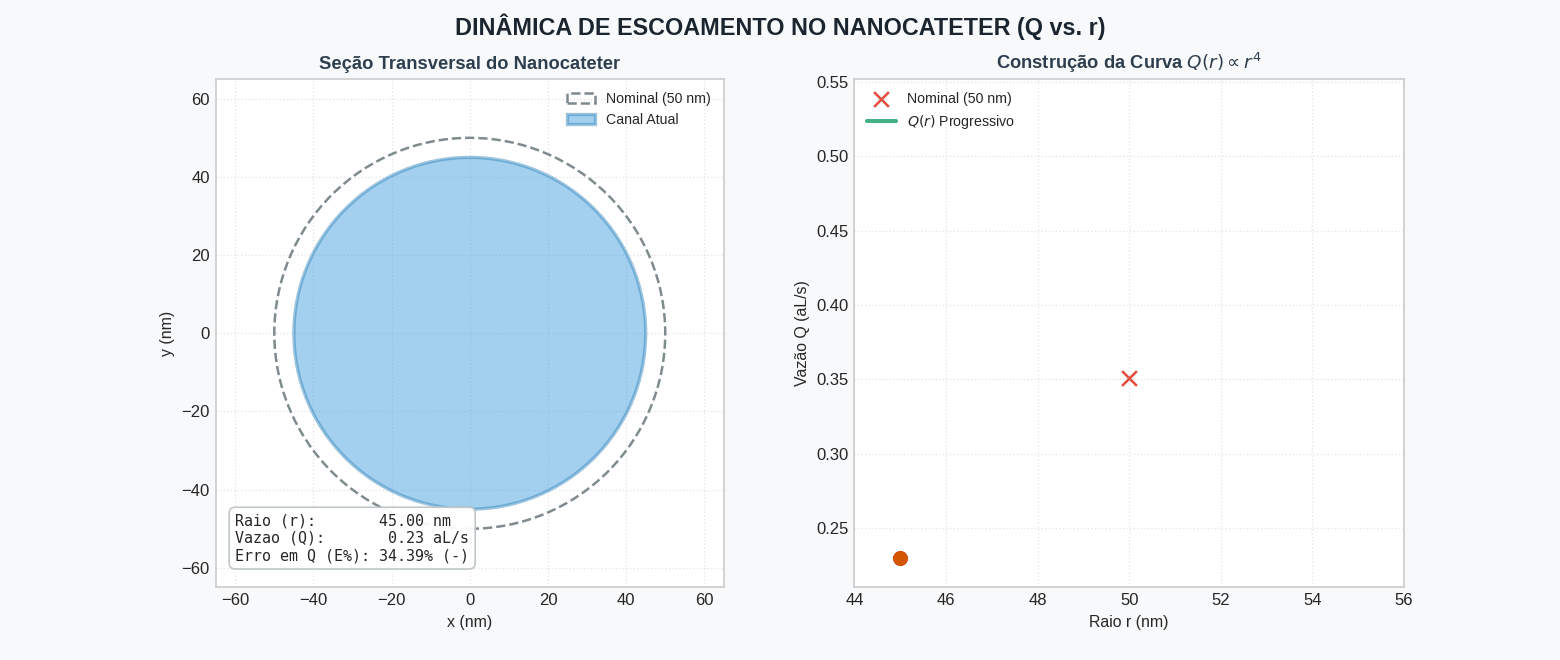

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from IPython.display import Image, display

# -----------------------------------------------------------------------------
# 1. Parâmetros Físicos do Nanocateter (Parte D)
# -----------------------------------------------------------------------------
L_nano = 10.0e-6        # Comprimento: 10 um (m)
mu_nano = 3.5e-3        # Viscosidade: 3.5e-3 Pa.s
dp_nano = 5000.0        # Diferenca de pressao: 5000 Pa
r_ref = 50.0e-9         # Raio de referencia: 50 nm (m)

def calc_Q(r):
    return (np.pi * (r ** 4) * dp_nano) / (8.0 * mu_nano * L_nano)

# Vazao de referencia (r = 50 nm)
Q_ref = calc_Q(r_ref)

# -----------------------------------------------------------------------------
# 2. Configuração dos Quadros da Animação (50 frames de 45 nm a 55 nm)
# -----------------------------------------------------------------------------
num_frames = 60
r_valores_nm = np.linspace(45.0, 55.0, num_frames)
r_valores_m = r_valores_nm * 1e-9
Q_valores_al = calc_Q(r_valores_m) * 1e18  # Convertido para aL/s (10^-18 L/s ou 10^-21 m^3/s)

# -----------------------------------------------------------------------------
# 3. Construção da Figura (2 Painéis)
# -----------------------------------------------------------------------------
fig, (ax_canal, ax_curva) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=120, facecolor="#f8f9fa")
fig.suptitle("DINÂMICA DE ESCOAMENTO NO NANOCATETER (Q vs. r)", fontsize=14, fontweight="bold", color="#1a252f", y=0.98)

# Painel 1: Seção Transversal do Canal
ax_canal.set_aspect("equal")
ax_canal.set_xlim(-65, 65)
ax_canal.set_ylim(-65, 65)
ax_canal.set_xlabel("x (nm)", fontsize=9.5)
ax_canal.set_ylabel("y (nm)", fontsize=9.5)
ax_canal.set_title("Seção Transversal do Nanocateter", fontsize=11, fontweight="bold", color="#2c3e50")
ax_canal.grid(True, linestyle=":", alpha=0.5)

# Círculo de referência fixo (50 nm)
circ_ref = Circle((0, 0), 50.0, fill=False, edgecolor="#7f8c8d", linestyle="--", linewidth=1.5, label="Nominal (50 nm)")
ax_canal.add_patch(circ_ref)

# Círculo dinâmico (área fluida)
circ_dinamico = Circle((0, 0), 45.0, facecolor="#3498db", alpha=0.45, edgecolor="#2980b9", linewidth=2.0, label="Canal Atual")
ax_canal.add_patch(circ_dinamico)
ax_canal.legend(loc="upper right", fontsize=8.5)

# Caixa de telemetria / HUD
texto_telemetria = ax_canal.text(
    -60, -58, "",
    fontsize=9.0,
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffffff", edgecolor="#bdc3c7", alpha=0.95)
)

# Painel 2: Curva Q x r Progressiva
ax_curva.set_xlim(44, 56)
ax_curva.set_ylim(calc_Q(44e-9)*1e18, calc_Q(56e-9)*1e18)
ax_curva.set_xlabel("Raio r (nm)", fontsize=9.5)
ax_curva.set_ylabel("Vazão Q (aL/s)", fontsize=9.5)
ax_curva.set_title(r"Construção da Curva $Q(r) \propto r^4$", fontsize=11, fontweight="bold", color="#2c3e50")
ax_curva.grid(True, linestyle=":", alpha=0.5)

# Ponto de referência nominal
ax_curva.scatter([50.0], [Q_ref * 1e18], color="#e74c3c", marker="x", s=80, zorder=5, label="Nominal (50 nm)")

# Elementos dinâmicos da curva
linha_trajetoria, = ax_curva.plot([], [], color="#27ae60", linewidth=2.2, label=r"$Q(r)$ Progressivo")
ponto_atual, = ax_curva.plot([], [], marker="o", markersize=8, color="#d35400", zorder=6)
ax_curva.legend(loc="upper left", fontsize=8.5)

# -----------------------------------------------------------------------------
# 4. Função de Atualização dos Quadros
# -----------------------------------------------------------------------------
def update(frame):
    r_atual = r_valores_nm[frame]
    Q_atual_al = Q_valores_al[frame]
    Q_atual_m3s = calc_Q(r_atual * 1e-9)

    # Cálculo do Erro Percentual em relação a r = 50 nm
    erro_perc = 100.0 * abs(Q_atual_m3s - Q_ref) / Q_ref
    sinal_variacao = "+" if r_atual >= 50.0 else "-"

    # Atualiza Seção Transversal
    circ_dinamico.set_radius(r_atual)
    texto_telemetria.set_text(
        f"Raio (r):       {r_atual:5.2f} nm\n"
        f"Vazao (Q):      {Q_atual_al:5.2f} aL/s\n"
        f"Erro em Q (E%): {erro_perc:5.2f}% ({sinal_variacao})"
    )

    # Atualiza Curva Progressiva e Ponto
    linha_trajetoria.set_data(r_valores_nm[:frame+1], Q_valores_al[:frame+1])
    ponto_atual.set_data([r_atual], [Q_atual_al])

    return circ_dinamico, texto_telemetria, linha_trajetoria, ponto_atual

# -----------------------------------------------------------------------------
# 5. Renderização e Salvamento do GIF
# -----------------------------------------------------------------------------
anim = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

nome_gif = "nanocateter_animacao.gif"
anim.save(nome_gif, writer=PillowWriter(fps=20))
plt.close(fig)

print(f"GIF animado gerado com sucesso: '{nome_gif}' (60 quadros, 20 FPS)")

# Exibe o GIF diretamente no notebook
display(Image(filename=nome_gif))

## Conclusão:
A partir dos cálculos, testes, tabelas e gráficos aqui realizidos, evidencia-se que o controle de erros numéricos e a análise da propagação de incertezas são fundamentais para a modelagem computacional autêntica de fenômenos físicos. Enquanto o arredondamento demonstrou superioridade sobre o truncamento ao mitigar desvios sistemáticos acumulados, a aplicação da equação de Hagen-Poiseuille revelou como relações não lineares ($Q \propto r^4$) amplificam criticamente pequenas variações no raio. Além disso, na nanoescala, o aumento da razão superfície/volume ($2/r$) exarceba essa sensibilidade geométrica e expõe a vulnerabilidade da máquina ao cancelamento catastrófico em diferenças de ordens infinitesimais, de modo a exigir formulações algebricamente estáveis e aritmética de precisão dupla (float64). Conclui-se que uma representação com elevada precisão de ponto flutuante não garante a validade física das estimativas quando as hipóteses clássicas do meio contínuo atingem seus limites de aplicação, porém métodos da modelagem numérica proporcionam o aprimoramento da análise computacional dos experimentos realizados.